# IPR Analysis (Pipeline Outputs)

This notebook visualizes IPR delta signals produced by `structural_benchmark.py` and documented in `IPR.md`.

It reads JSON runs from `analysis_out/rome_structural_*.json` and covers:

1. **Delta signals** — per-layer change in c_proj IPR after edit (requires baseline)
2. **Layer ranking** — top layers by |delta| (requires baseline)
3. **Gap delta heatmap** — all delta metrics as heatmap (requires baseline)
4. **Blind analysis** — c_proj vs c_fc on *only* the edited model
5. **Extended blind analysis** — row/column distribution shape (skewness, kurtosis, IQR)
6. **Z-score anomaly detection** — the `IPRDetector` blind approach
7. **Aggregate detection accuracy** — across multiple test cases


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150})

ROOT = Path.cwd()
candidates = [
    ROOT / 'analysis_out',
    ROOT.parent / 'analysis_out',
    Path('./analysis_out'),
    Path('../analysis_out'),
]

ANALYSIS_DIR = None
for candidate in candidates:
    p = Path(candidate).expanduser().resolve()
    if p.exists() and p.is_dir():
        ANALYSIS_DIR = p
        break

if ANALYSIS_DIR is None:
    searched = '\n'.join(str(Path(c).expanduser().resolve()) for c in candidates)
    raise FileNotFoundError(f'analysis_out not found. Searched:\n{searched}')

run_files = sorted(ANALYSIS_DIR.glob('rome_structural_*.json'))
if not run_files:
    raise FileNotFoundError(f'No rome_structural_*.json found in {ANALYSIS_DIR}')

for idx, p in enumerate(run_files[-10:]):
    print(f'[{idx - min(10, len(run_files))}] {p.name}')

RUN_INDEX = -1  # set to another negative index to inspect older runs
RUN_PATH = run_files[RUN_INDEX]
print('\nSelected run:', RUN_PATH.name)
print('Using analysis directory:', ANALYSIS_DIR)


[-10] rome_structural_gpt2-large_2026-02-24_14-25-32.json
[-9] rome_structural_gpt2-large_2026-02-24_14-31-58.json
[-8] rome_structural_gpt2-large_2026-02-24_14-36-14.json
[-7] rome_structural_gpt2-large_2026-02-25_10-54-57.json
[-6] rome_structural_gpt2-large_2026-02-25_11-02-25.json
[-5] rome_structural_gpt2-large_2026-02-25_11-06-27.json
[-4] rome_structural_gpt2-large_2026-02-25_11-43-38.json
[-3] rome_structural_gpt2-large_2026-02-25_12-45-20.json
[-2] rome_structural_gpt2-large_2026-02-25_12-55-46.json
[-1] rome_structural_gpt2-medium_2026-02-25_13-05-02.json

Selected run: rome_structural_gpt2-medium_2026-02-25_13-05-02.json
Using analysis directory: /home/metju/reimagined/analysis_out


In [2]:
with RUN_PATH.open('r') as f:
    run_data = json.load(f)

metadata = run_data.get('metadata', {})
tests = run_data.get('tests', [])
summary = run_data.get('summary', {})
target_layer = metadata.get('target_layer')

# Filter to non-skipped tests
good_tests = [t for t in tests if not t.get('skipped', False)]

print('Model:', metadata.get('model'))
print('Target layer:', target_layer)
print('Timestamp:', metadata.get('timestamp'))
print(f'Tests in run: {len(tests)} total, {len(good_tests)} successful')
print('Summary:', summary)

# Check what IPR data is available
sample_ipr = good_tests[0].get('ipr', {}) if good_tests else {}
print('\nIPR data keys:', list(sample_ipr.keys()))
has_extended = 'extended_fc_vs_proj' in sample_ipr
has_ipr_detection = 'ipr_detection' in sample_ipr
print(f'Extended IPR data: {has_extended}')
print(f'IPR detector results: {has_ipr_detection}')


Model: gpt2-medium
Target layer: 8
Timestamp: 2026-02-25T13:04:31.286619
Tests in run: 1 total, 1 successful
Summary: {'total_tests': 1, 'successful_tests': 1, 'skipped_tests': 0, 'rome_success_rate': 1.0, 'normal_detection_accuracy': 1.0, 'blind_detection_accuracy': 0.0, 'spectral_detection_accuracy': 1.0, 'ipr_detection_accuracy': 0.0}

IPR data keys: ['c_proj', 'c_proj_delta_from_baseline', 'fc_vs_proj', 'fc_vs_proj_delta_from_baseline', 'ipr_detection']
Extended IPR data: False
IPR detector results: True


## IPR Delta Signals (single test)

This reproduces the core signal view described in `IPR.md`: delta metrics over layer index for one test case.

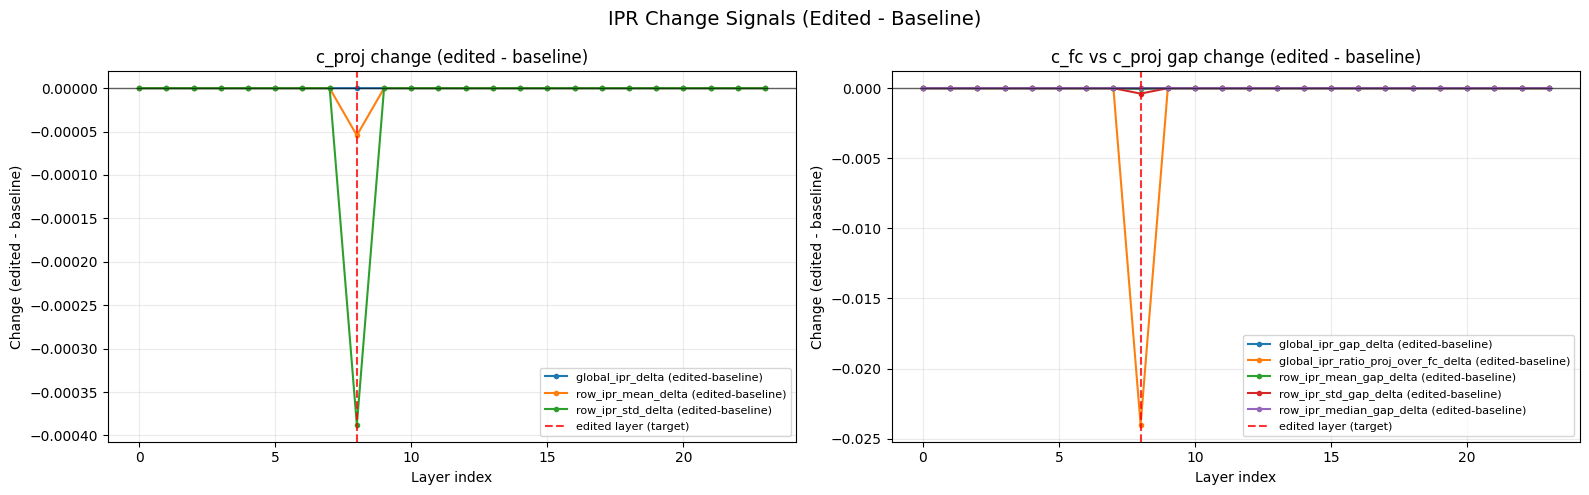

In [15]:
def delta_series(delta_dict, metric_name):
    rows = []
    for layer_str, metrics in delta_dict.items():
        layer = int(layer_str)
        val = float(metrics.get(metric_name, np.nan))
        rows.append((layer, val))
    rows.sort(key=lambda x: x[0])
    x = np.array([r[0] for r in rows], dtype=int)
    y = np.array([r[1] for r in rows], dtype=float)
    return x, y


def plot_ipr_delta_signals(test_entry, target_layer=None):
    ipr = test_entry.get('ipr', {})
    cproj_delta = ipr.get('c_proj_delta_from_baseline', {})
    gap_delta = ipr.get('fc_vs_proj_delta_from_baseline', {})

    if not cproj_delta and not gap_delta:
        raise ValueError('This test entry has no edited-vs-baseline IPR change data.')

    cproj_metrics = [
        'global_ipr_delta',
        'row_ipr_mean_delta',
        'row_ipr_std_delta',
    ]
    gap_metrics = [
        'global_ipr_gap_delta',
        'global_ipr_ratio_proj_over_fc_delta',
        'row_ipr_mean_gap_delta',
        'row_ipr_std_gap_delta',
        'row_ipr_median_gap_delta',
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

    for metric in cproj_metrics:
        x, y = delta_series(cproj_delta, metric)
        axes[0].plot(x, y, marker='o', markersize=3, linewidth=1.5, label=f'{metric} (edited-baseline)')

    for metric in gap_metrics:
        x, y = delta_series(gap_delta, metric)
        axes[1].plot(x, y, marker='o', markersize=3, linewidth=1.5, label=f'{metric} (edited-baseline)')

    for ax, title in zip(axes, ['c_proj change (edited - baseline)', 'c_fc vs c_proj gap change (edited - baseline)']):
        ax.axhline(0.0, color='black', linewidth=1, alpha=0.6)
        if target_layer is not None:
            ax.axvline(int(target_layer), color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='edited layer (target)')
        ax.set_title(title)
        ax.set_xlabel('Layer index')
        ax.set_ylabel('Change (edited - baseline)')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best', fontsize=8)

    fig.suptitle('IPR Change Signals (Edited - Baseline)', fontsize=14)
    fig.tight_layout()
    plt.show()


TEST_INDEX = 0  # change if a run has multiple tests
if not tests:
    raise ValueError('No tests found in selected run.')

plot_ipr_delta_signals(tests[TEST_INDEX], target_layer=metadata.get('target_layer'))

In [4]:
def rank_layers_by_abs_delta(test_entry, metric='global_ipr_gap_delta', top_k=10):
    delta_dict = test_entry.get('ipr', {}).get('fc_vs_proj_delta_from_baseline', {})
    ranking = []
    for layer_str, metrics in delta_dict.items():
        layer = int(layer_str)
        value = float(metrics.get(metric, 0.0))
        ranking.append((layer, value, abs(value)))

    ranking.sort(key=lambda x: x[2], reverse=True)
    return ranking[:top_k]

print('Top layers by |global_ipr_gap_delta|')
for layer, value, abs_value in rank_layers_by_abs_delta(tests[TEST_INDEX], 'global_ipr_gap_delta', top_k=10):
    marker = ' <== target' if layer == metadata.get('target_layer') else ''
    print(f'layer {layer:>2}: value={value:+.6e}, abs={abs_value:.6e}{marker}')

print('\nTop layers by |global_ipr_delta| (c_proj)')
cproj_delta = tests[TEST_INDEX].get('ipr', {}).get('c_proj_delta_from_baseline', {})
rows = []
for layer_str, metrics in cproj_delta.items():
    layer = int(layer_str)
    value = float(metrics.get('global_ipr_delta', 0.0))
    rows.append((layer, value, abs(value)))
rows.sort(key=lambda x: x[2], reverse=True)
for layer, value, abs_value in rows[:10]:
    marker = ' <== target' if layer == metadata.get('target_layer') else ''
    print(f'layer {layer:>2}: value={value:+.6e}, abs={abs_value:.6e}{marker}')

Top layers by |global_ipr_gap_delta|
layer  8: value=-2.070101e-08, abs=2.070101e-08 <== target
layer  0: value=+0.000000e+00, abs=0.000000e+00
layer  1: value=+0.000000e+00, abs=0.000000e+00
layer  2: value=+0.000000e+00, abs=0.000000e+00
layer  3: value=+0.000000e+00, abs=0.000000e+00
layer  4: value=+0.000000e+00, abs=0.000000e+00
layer  5: value=+0.000000e+00, abs=0.000000e+00
layer  6: value=+0.000000e+00, abs=0.000000e+00
layer  7: value=+0.000000e+00, abs=0.000000e+00
layer  9: value=+0.000000e+00, abs=0.000000e+00

Top layers by |global_ipr_delta| (c_proj)
layer  8: value=-2.070101e-08, abs=2.070101e-08 <== target
layer  0: value=+0.000000e+00, abs=0.000000e+00
layer  1: value=+0.000000e+00, abs=0.000000e+00
layer  2: value=+0.000000e+00, abs=0.000000e+00
layer  3: value=+0.000000e+00, abs=0.000000e+00
layer  4: value=+0.000000e+00, abs=0.000000e+00
layer  5: value=+0.000000e+00, abs=0.000000e+00
layer  6: value=+0.000000e+00, abs=0.000000e+00
layer  7: value=+0.000000e+00, abs

## Aggregate across tests (if available)

If a run has multiple tests, this plot shows mean absolute delta per layer.

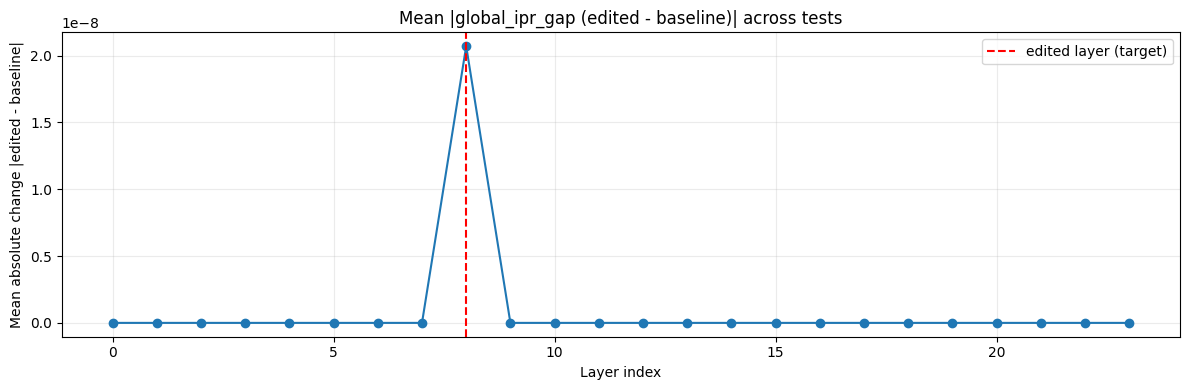

In [16]:
def aggregate_abs_metric(tests, source_key, metric_name):
    per_layer = {}
    for t in tests:
        delta_dict = t.get('ipr', {}).get(source_key, {})
        for layer_str, metrics in delta_dict.items():
            layer = int(layer_str)
            val = abs(float(metrics.get(metric_name, 0.0)))
            per_layer.setdefault(layer, []).append(val)

    layers = sorted(per_layer.keys())
    means = np.array([np.mean(per_layer[layer]) for layer in layers], dtype=float)
    return np.array(layers, dtype=int), means

layers, mean_abs_gap = aggregate_abs_metric(
    tests,
    source_key='fc_vs_proj_delta_from_baseline',
    metric_name='global_ipr_gap_delta',
)

plt.figure(figsize=(12, 4))
plt.plot(layers, mean_abs_gap, marker='o', linewidth=1.5)
if metadata.get('target_layer') is not None:
    plt.axvline(int(metadata['target_layer']), color='red', linestyle='--', linewidth=1.5, label='edited layer (target)')
plt.title('Mean |global_ipr_gap (edited - baseline)| across tests')
plt.xlabel('Layer index')
plt.ylabel('Mean absolute change |edited - baseline|')
plt.grid(True, alpha=0.25)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Baseline: c_proj vs c_fc global IPR per layer

`fc_vs_proj` stores absolute (pre-edit) IPR for both matrices. Plotting them together shows the natural concentration gap that ROME disturbs at the target layer.


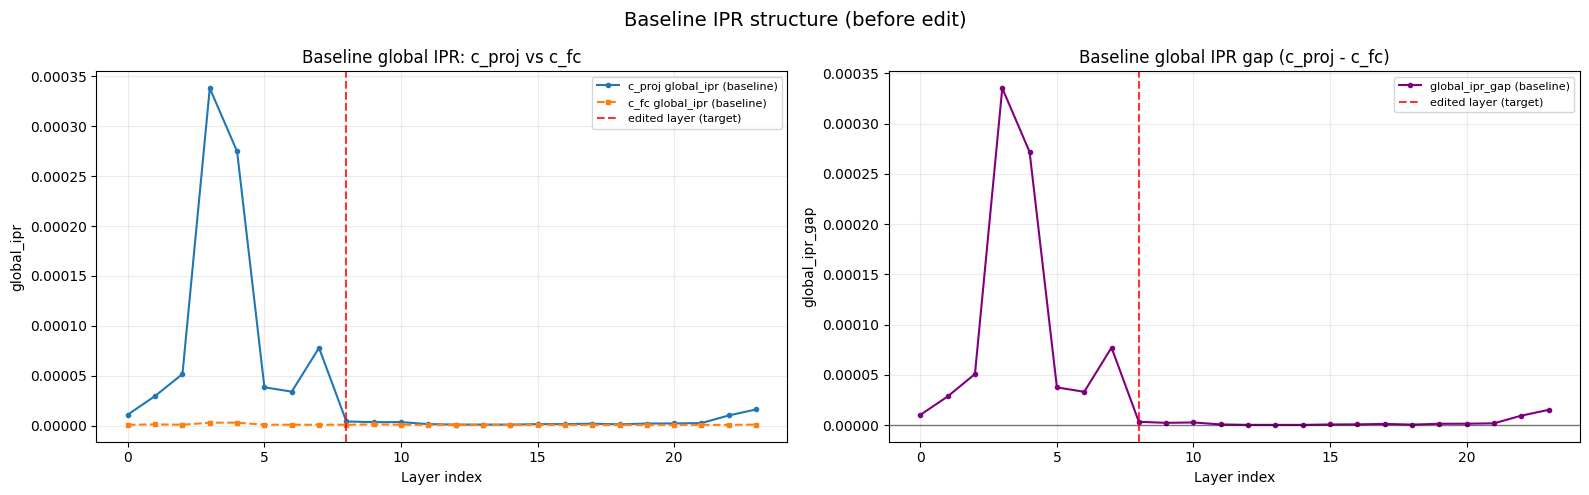

In [17]:
def extract_fc_vs_proj_series(test_entry, metric):
    """Extract a per-layer series from the fc_vs_proj (baseline) dict."""
    fvp = test_entry.get('ipr', {}).get('fc_vs_proj', {})
    rows = []
    for layer_str, m in fvp.items():
        rows.append((int(layer_str), float(m.get(metric, np.nan))))
    rows.sort()
    return np.array([r[0] for r in rows], dtype=int), np.array([r[1] for r in rows], dtype=float)


lx, proj_ipr = extract_fc_vs_proj_series(tests[TEST_INDEX], 'proj_global_ipr')
_, fc_ipr    = extract_fc_vs_proj_series(tests[TEST_INDEX], 'fc_global_ipr')
_, gap_ipr   = extract_fc_vs_proj_series(tests[TEST_INDEX], 'global_ipr_gap')

target_layer = metadata.get('target_layer')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: absolute IPR for both matrices
axes[0].plot(lx, proj_ipr, marker='o', markersize=3, linewidth=1.5, label='c_proj global_ipr (baseline)')
axes[0].plot(lx, fc_ipr,   marker='s', markersize=3, linewidth=1.5, label='c_fc global_ipr (baseline)',  linestyle='--')
if target_layer is not None:
    axes[0].axvline(int(target_layer), color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='edited layer (target)')
axes[0].set_title('Baseline global IPR: c_proj vs c_fc')
axes[0].set_xlabel('Layer index')
axes[0].set_ylabel('global_ipr')
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc='best', fontsize=8)

# Right: baseline gap (proj − fc)
axes[1].plot(lx, gap_ipr, marker='o', markersize=3, linewidth=1.5, color='purple', label='global_ipr_gap (baseline)')
axes[1].axhline(0.0, color='black', linewidth=1, alpha=0.5)
if target_layer is not None:
    axes[1].axvline(int(target_layer), color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='edited layer (target)')
axes[1].set_title('Baseline global IPR gap (c_proj - c_fc)')
axes[1].set_xlabel('Layer index')
axes[1].set_ylabel('global_ipr_gap')
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc='best', fontsize=8)

fig.suptitle('Baseline IPR structure (before edit)', fontsize=14)
fig.tight_layout()
plt.show()


## Layer ranking: top layers by |delta| (bar chart)

Horizontal bar chart of the top-N layers ranked by `|global_ipr_gap_delta|`. The target layer should stand out clearly.


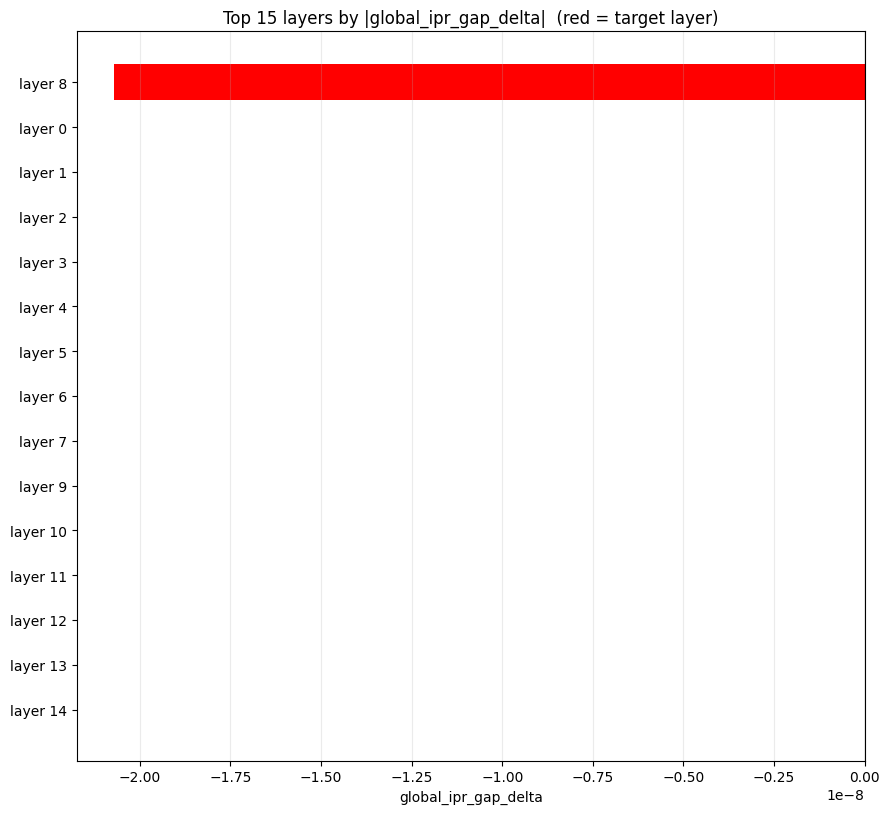

In [7]:
def plot_layer_ranking_bar(test_entry, target_layer=None, metric='global_ipr_gap_delta', top_k=15):
    delta_dict = test_entry.get('ipr', {}).get('fc_vs_proj_delta_from_baseline', {})
    rows = []
    for layer_str, m in delta_dict.items():
        layer = int(layer_str)
        value = float(m.get(metric, 0.0))
        rows.append((layer, value, abs(value)))
    rows.sort(key=lambda x: x[2], reverse=True)
    top = rows[:top_k]

    labels = [f'layer {r[0]}' for r in top]
    values = [r[1] for r in top]
    colors = ['red' if (target_layer is not None and r[0] == target_layer) else 'steelblue' for r in top]

    fig, ax = plt.subplots(figsize=(9, top_k * 0.45 + 1.5))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'{metric} (edited - baseline)')
    ax.set_title(f'Top {top_k} layers by |{metric}|  (red = edited layer target)')
    ax.grid(True, axis='x', alpha=0.25)
    fig.tight_layout()
    plt.show()

plot_layer_ranking_bar(tests[TEST_INDEX], target_layer=metadata.get('target_layer'), top_k=15)


## Gap delta heatmap: metrics × layers

All `fc_vs_proj_delta_from_baseline` metrics plotted as a heatmap. Each row is a metric, each column a layer. The edited layer lights up as a column anomaly.


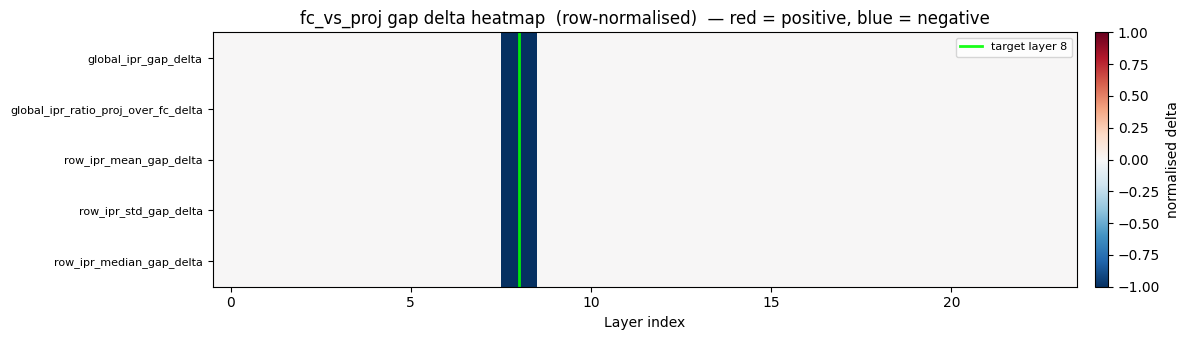

In [8]:
def plot_gap_delta_heatmap(test_entry, target_layer=None):
    delta_dict = test_entry.get('ipr', {}).get('fc_vs_proj_delta_from_baseline', {})
    gap_metrics = [
        'global_ipr_gap_delta',
        'global_ipr_ratio_proj_over_fc_delta',
        'row_ipr_mean_gap_delta',
        'row_ipr_std_gap_delta',
        'row_ipr_median_gap_delta',
    ]

    layers_sorted = sorted(int(k) for k in delta_dict.keys())
    matrix = np.zeros((len(gap_metrics), len(layers_sorted)), dtype=float)
    for col, layer in enumerate(layers_sorted):
        m = delta_dict[str(layer)]
        for row, metric in enumerate(gap_metrics):
            matrix[row, col] = float(m.get(metric, 0.0))

    # Normalise each row by its max |value| so all metrics share the same colour scale
    row_max = np.abs(matrix).max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1.0
    matrix_norm = matrix / row_max

    fig, ax = plt.subplots(figsize=(max(12, len(layers_sorted) * 0.35), 3.5))
    im = ax.imshow(matrix_norm, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1,
                   extent=[-0.5, len(layers_sorted) - 0.5, -0.5, len(gap_metrics) - 0.5])

    ax.set_yticks(range(len(gap_metrics)))
    ax.set_yticklabels(gap_metrics[::-1], fontsize=8)

    xtick_pos = [i for i, l in enumerate(layers_sorted) if l % 5 == 0]
    xtick_labels = [str(layers_sorted[i]) for i in xtick_pos]
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('Layer index')
    ax.set_title('c_fc vs c_proj gap change heatmap (edited - baseline, row-normalised)')

    if target_layer is not None:
        try:
            col_idx = layers_sorted.index(int(target_layer))
            ax.axvline(col_idx, color='lime', linewidth=2, alpha=0.9, label=f'edited layer (target={target_layer})')
            ax.legend(loc='upper right', fontsize=8)
        except ValueError:
            pass

    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='normalised change (edited - baseline)')
    fig.tight_layout()
    plt.show()

plot_gap_delta_heatmap(tests[TEST_INDEX], target_layer=metadata.get('target_layer'))

## Blind analysis: Z-score anomaly on gap profile

**No baseline needed.** We compute the z-score of each layer's `global_ipr_gap` (c_proj − c_fc) relative to the distribution across all layers. The edited layer may appear as a z-score outlier because ROME disturbed only its `c_proj`.

We also look at the **ratio** (c_proj / c_fc) and **second-order smoothness** (2nd finite differences) to catch kinks in otherwise smooth profiles.


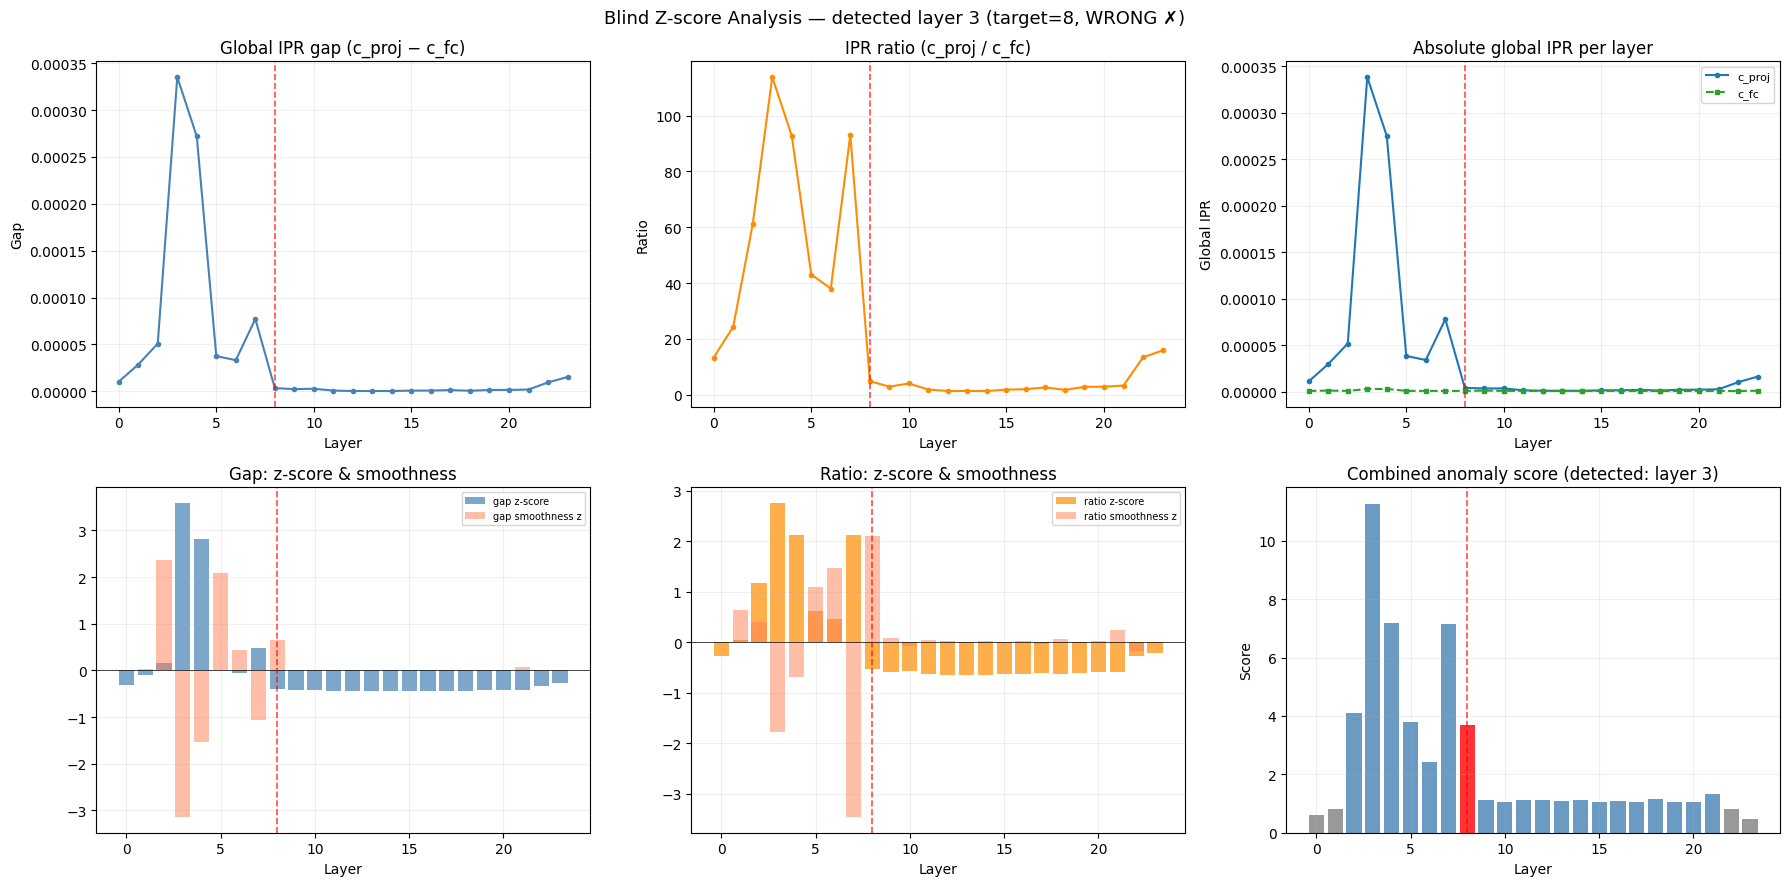


Detected layer: 3  (target: 8)  ✗ WRONG

Top-5 layers by combined score:
  1. layer  3: score=11.264
  2. layer  4: score=7.169
  3. layer  7: score=7.135
  4. layer  2: score=4.100
  5. layer  5: score=3.799


In [9]:
def zscore_blind_analysis(test_entry, target_layer=None, trim_first=2, trim_last=2):
    """Z-score analysis on the blind c_proj vs c_fc gap profile."""
    fvp = test_entry.get('ipr', {}).get('fc_vs_proj', {})
    if not fvp:
        print('No fc_vs_proj data in test entry (this run may be too old).')
        return

    # Extract per-layer metrics
    layers = sorted(int(k) for k in fvp.keys())
    gap = np.array([fvp[str(l)]['global_ipr_gap'] for l in layers])
    ratio = np.array([fvp[str(l)]['global_ipr_ratio_proj_over_fc'] for l in layers])
    proj_ipr = np.array([fvp[str(l)]['proj_global_ipr'] for l in layers])
    fc_ipr = np.array([fvp[str(l)]['fc_global_ipr'] for l in layers])

    # Z-scores
    def z(arr):
        m, s = arr.mean(), arr.std()
        return (arr - m) / (s if s > 0 else 1.0)

    gap_z = z(gap)
    ratio_z = z(ratio)

    # Second-order finite differences (smoothness)
    def smooth_residual(arr):
        d2 = np.zeros_like(arr)
        d2[1:-1] = arr[2:] - 2*arr[1:-1] + arr[:-2]
        return z(d2)

    gap_smooth = smooth_residual(gap)
    ratio_smooth = smooth_residual(ratio)

    # Combined score: |z| + |smooth_residual|
    combined = np.abs(gap_z) + np.abs(gap_smooth) + np.abs(ratio_z) + np.abs(ratio_smooth)

    # Apply trim
    trimmed_combined = combined.copy()
    trimmed_combined[:trim_first] = 0
    trimmed_combined[-trim_last:] = 0

    detected_layer = layers[np.argmax(trimmed_combined)]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    # Row 1: raw profiles
    axes[0, 0].plot(layers, gap, 'o-', markersize=3, linewidth=1.5, color='steelblue')
    axes[0, 0].set_title('Global IPR gap (c_proj − c_fc)')
    axes[0, 0].set_xlabel('Layer')
    axes[0, 0].set_ylabel('Gap')

    axes[0, 1].plot(layers, ratio, 'o-', markersize=3, linewidth=1.5, color='darkorange')
    axes[0, 1].set_title('IPR ratio (c_proj / c_fc)')
    axes[0, 1].set_xlabel('Layer')
    axes[0, 1].set_ylabel('Ratio')

    axes[0, 2].plot(layers, proj_ipr, 'o-', markersize=3, linewidth=1.5, label='c_proj', color='tab:blue')
    axes[0, 2].plot(layers, fc_ipr, 's--', markersize=3, linewidth=1.5, label='c_fc', color='tab:green')
    axes[0, 2].set_title('Absolute global IPR per layer')
    axes[0, 2].set_xlabel('Layer')
    axes[0, 2].set_ylabel('Global IPR')
    axes[0, 2].legend(fontsize=8)

    # Row 2: z-scores and combined
    axes[1, 0].bar(layers, gap_z, color='steelblue', alpha=0.7, label='gap z-score')
    axes[1, 0].bar(layers, gap_smooth, color='coral', alpha=0.5, label='gap smoothness z')
    axes[1, 0].axhline(0, color='black', linewidth=0.5)
    axes[1, 0].set_title('Gap: z-score & smoothness')
    axes[1, 0].set_xlabel('Layer')
    axes[1, 0].legend(fontsize=7)

    axes[1, 1].bar(layers, ratio_z, color='darkorange', alpha=0.7, label='ratio z-score')
    axes[1, 1].bar(layers, ratio_smooth, color='coral', alpha=0.5, label='ratio smoothness z')
    axes[1, 1].axhline(0, color='black', linewidth=0.5)
    axes[1, 1].set_title('Ratio: z-score & smoothness')
    axes[1, 1].set_xlabel('Layer')
    axes[1, 1].legend(fontsize=7)

    colors = ['red' if layers[i] == target_layer else ('gray' if trimmed_combined[i] == 0 else 'steelblue')
              for i in range(len(layers))]
    axes[1, 2].bar(layers, combined, color=colors, alpha=0.8)
    axes[1, 2].axhline(0, color='black', linewidth=0.5)
    axes[1, 2].set_title(f'Combined anomaly score (detected: layer {detected_layer})')
    axes[1, 2].set_xlabel('Layer')
    axes[1, 2].set_ylabel('Score')

    for ax_row in axes:
        for ax in ax_row:
            if target_layer is not None:
                ax.axvline(int(target_layer), color='red', linestyle='--', linewidth=1.2, alpha=0.7)
            ax.grid(True, alpha=0.2)

    correct = detected_layer == target_layer
    fig.suptitle(f'Blind Z-score Analysis — detected layer {detected_layer} '
                 f'(target={target_layer}, {"CORRECT ✓" if correct else "WRONG ✗"})', fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f'\nDetected layer: {detected_layer}  (target: {target_layer})  {"✓ CORRECT" if correct else "✗ WRONG"}')
    print(f'\nTop-5 layers by combined score:')
    ranking = sorted(zip(layers, combined.tolist()), key=lambda x: x[1], reverse=True)
    for i, (l, s) in enumerate(ranking[:5]):
        flag = ' <== target' if l == target_layer else ''
        print(f'  {i+1}. layer {l:>2}: score={s:.3f}{flag}')

TEST_INDEX = 0
zscore_blind_analysis(good_tests[TEST_INDEX], target_layer=target_layer)


## Extended blind analysis: Row/column distribution shape

If the run includes `extended_fc_vs_proj` data, we can compare the **distribution shape** (skewness, kurtosis, IQR, max/median ratio) of row-wise and column-wise IPR between c_proj and c_fc per layer.

ROME applies a rank-1 update to c_proj, which may:
- Make specific rows have disproportionately high IPR → higher **row kurtosis** or **row max/median**
- Make specific columns have shifted concentration → detectable in **column IPR stats**


In [10]:
def plot_extended_blind_analysis(test_entry, target_layer=None, trim_first=2, trim_last=2):
    """Visualise extended distribution-shape features for blind detection."""
    ext_fvp = test_entry.get('ipr', {}).get('extended_fc_vs_proj', {})
    if not ext_fvp:
        # Fall back: try to compute from the basic fc_vs_proj
        print('No extended_fc_vs_proj data. Run needs the updated benchmark.')
        return

    layers = sorted(int(k) for k in ext_fvp.keys())
    n = len(layers)

    # Gather extended gap metrics
    metrics_to_plot = [
        ('row_skewness_gap', 'Row skewness gap (proj − fc)'),
        ('row_kurtosis_gap', 'Row kurtosis gap (proj − fc)'),
        ('row_iqr_gap', 'Row IQR gap (proj − fc)'),
        ('row_max_over_median_gap', 'Row max/median gap (proj − fc)'),
        ('col_ipr_skewness_gap', 'Col skewness gap (proj − fc)'),
        ('col_ipr_kurtosis_gap', 'Col kurtosis gap (proj − fc)'),
    ]

    available = [(key, label) for key, label in metrics_to_plot
                 if key in ext_fvp[str(layers[0])]]

    if not available:
        print('Extended gap metrics not found in the data.')
        return

    n_metrics = len(available)
    ncols = 3
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), squeeze=False)

    for idx, (key, label) in enumerate(available):
        ax = axes[idx // ncols][idx % ncols]
        vals = np.array([ext_fvp[str(l)].get(key, 0.0) for l in layers])

        # Z-score for colouring
        m, s = vals.mean(), vals.std()
        z_vals = (vals - m) / (s if s > 0 else 1.0)

        colors = []
        for i, l in enumerate(layers):
            if l == target_layer:
                colors.append('red')
            elif i < trim_first or i >= n - trim_last:
                colors.append('lightgray')
            elif abs(z_vals[i]) > 2.5:
                colors.append('darkorange')
            else:
                colors.append('steelblue')

        ax.bar(layers, vals, color=colors, alpha=0.8)
        ax.axhline(m, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Layer')
        ax.grid(True, alpha=0.2)
        if target_layer is not None:
            ax.axvline(int(target_layer), color='red', linestyle='--', linewidth=1, alpha=0.6)

    # Hide unused axes
    for idx in range(len(available), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle('Extended blind analysis: distribution shape gaps (c_proj vs c_fc)\n'
                 'red bar = target layer, orange = |z| > 2.5, gray = trimmed', fontsize=12)
    fig.tight_layout()
    plt.show()

if good_tests:
    plot_extended_blind_analysis(good_tests[TEST_INDEX], target_layer=target_layer)
else:
    print('No successful tests to analyse.')


No extended_fc_vs_proj data. Run needs the updated benchmark.


## IPR Detector results (from benchmark)

If the benchmark was run with the updated code, `ipr_detection` stores the full output of `IPRDetector.detect()` — including per-layer combined scores, feature z-scores, and the final detected layer.


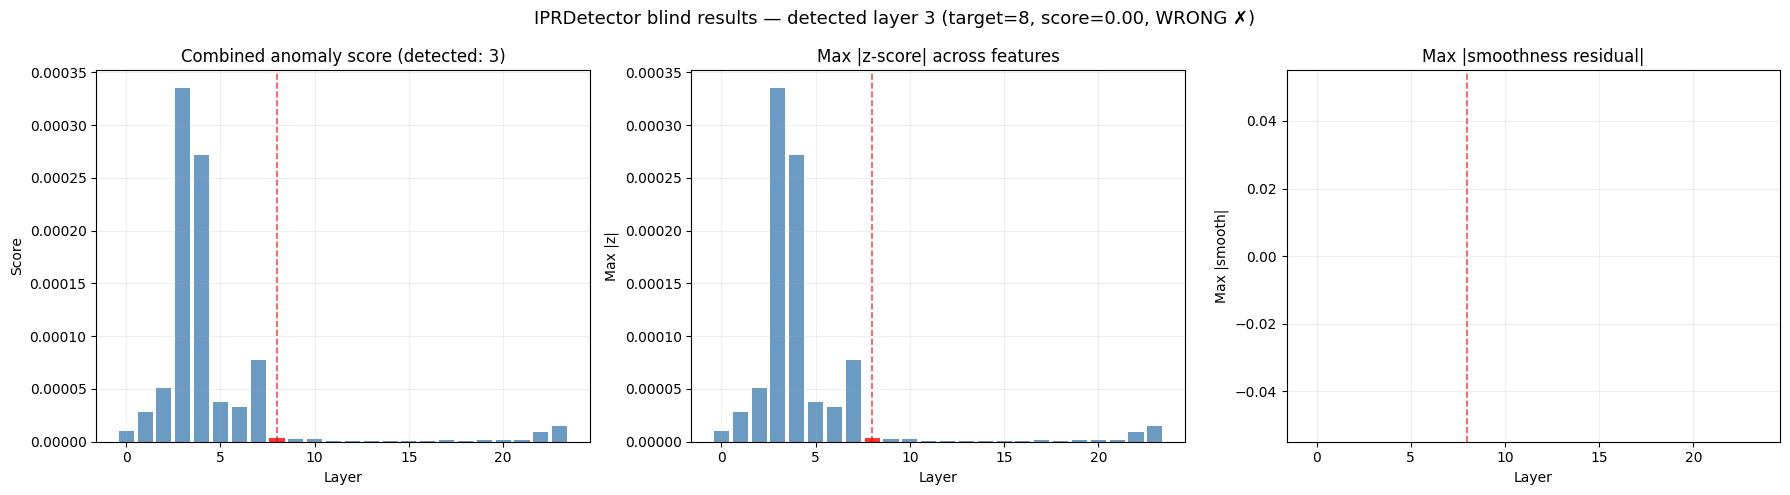


Feature z-scores at target layer 8:
                            global_ipr_gap: z = +0.000

Layer ranking (top 10):
  1. layer  3: score=0.000
  2. layer  4: score=0.000
  3. layer  7: score=0.000
  4. layer  2: score=0.000
  5. layer  5: score=0.000
  6. layer  6: score=0.000
  7. layer  1: score=0.000
  8. layer 23: score=0.000
  9. layer  0: score=0.000
  10. layer 22: score=0.000


In [11]:
def plot_ipr_detector_results(test_entry, target_layer=None):
    """Visualise the IPRDetector output saved in the benchmark JSON."""
    det = test_entry.get('ipr', {}).get('ipr_detection', {})
    if not det:
        print('No ipr_detection data available (run updated benchmark).')
        return

    per_layer = det.get('per_layer', {})
    if not per_layer:
        print('per_layer data missing from ipr_detection.')
        return

    layers = sorted(int(k) for k in per_layer.keys())
    combined = np.array([per_layer[str(l)]['combined_score'] for l in layers])
    max_z = np.array([per_layer[str(l)]['max_abs_z'] for l in layers])
    max_smooth = np.array([per_layer[str(l)]['max_abs_smooth'] for l in layers])

    detected = det.get('anomalous_layer')
    score = det.get('anomaly_score', 0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Combined score
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    axes[0].bar(layers, combined, color=colors, alpha=0.8)
    axes[0].set_title(f'Combined anomaly score (detected: {detected})')
    axes[0].set_xlabel('Layer')
    axes[0].set_ylabel('Score')

    # 2) Max |z-score| across features
    axes[1].bar(layers, max_z, color=colors, alpha=0.8)
    axes[1].set_title('Max |z-score| across features')
    axes[1].set_xlabel('Layer')
    axes[1].set_ylabel('Max |z|')

    # 3) Max |smoothness residual| across features
    axes[2].bar(layers, max_smooth, color=colors, alpha=0.8)
    axes[2].set_title('Max |smoothness residual|')
    axes[2].set_xlabel('Layer')
    axes[2].set_ylabel('Max |smooth|')

    for ax in axes:
        if target_layer is not None:
            ax.axvline(float(target_layer), color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.grid(True, alpha=0.2)

    correct = detected == target_layer
    fig.suptitle(f'IPRDetector blind results — detected layer {detected} '
                 f'(target={target_layer}, score={score:.2f}, {"CORRECT ✓" if correct else "WRONG ✗"})',
                 fontsize=13)
    fig.tight_layout()
    plt.show()

    # Print feature z-scores for the detected (or target) layer
    focus_layer = target_layer if target_layer is not None else detected
    if focus_layer is not None and str(focus_layer) in per_layer:
        zs = per_layer[str(focus_layer)].get('z_scores', {})
        print(f'\nFeature z-scores at target layer {focus_layer}:')
        for feat, val in sorted(zs.items(), key=lambda x: abs(x[1]), reverse=True):
            print(f'  {feat:>40s}: z = {val:+.3f}')

    # Ranking
    ranking = det.get('ranking', [])
    if ranking:
        print(f'\nLayer ranking (top 10):')
        for i, (l, s) in enumerate(ranking[:10]):
            flag = ' <== target' if l == target_layer else ''
            print(f'  {i+1}. layer {l:>2}: score={s:.3f}{flag}')

if good_tests:
    plot_ipr_detector_results(good_tests[TEST_INDEX], target_layer=target_layer)


## Aggregate detection accuracy across all tests

For runs with multiple tests, this section computes how often each detection method correctly identifies the target layer, and how the blind IPR z-score approach compares.


Detection accuracy across 1 tests (target layer = 8):
Method                     Correct   Accuracy
---------------------------------------------
normal                        1/1     100.0%
blind                         0/1       0.0%
spectral                      1/1     100.0%
ipr_detection                 0/1       0.0%
zscore_blind                  0/1       0.0%

Z-score blind — target in top-3: 0/1 (0.0%)


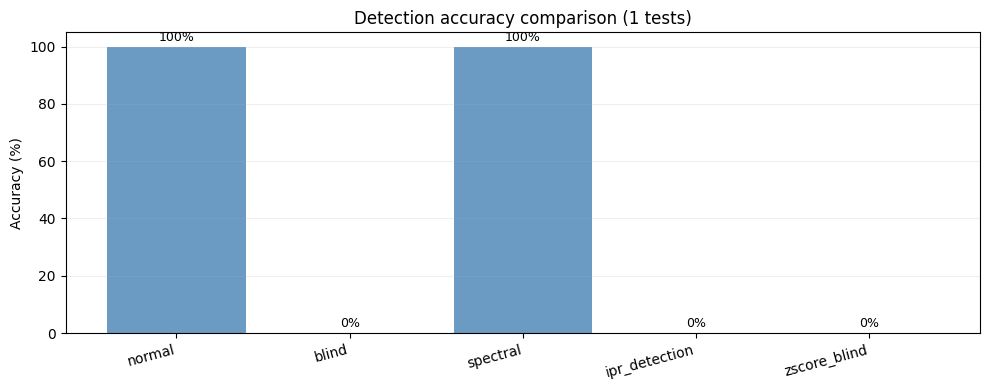

In [12]:
def aggregate_accuracy(tests, target_layer, trim_first=2, trim_last=2):
    """Compute detection accuracy of the blind IPR z-score approach
    and compare with other detectors (if available)."""

    methods = {}
    # Standard detectors
    for key in ('normal_correct', 'blind_correct', 'spectral_correct', 'ipr_detection_correct'):
        hits = sum(1 for t in tests if t.get('accuracy', {}).get(key, False))
        methods[key.replace('_correct', '')] = hits

    # Our own z-score blind analysis (recomputed)
    zscore_hits = 0
    zscore_top3 = 0
    for t in tests:
        fvp = t.get('ipr', {}).get('fc_vs_proj', {})
        if not fvp:
            continue
        layers = sorted(int(k) for k in fvp.keys())
        gap = np.array([fvp[str(l)]['global_ipr_gap'] for l in layers])
        ratio = np.array([fvp[str(l)]['global_ipr_ratio_proj_over_fc'] for l in layers])

        def z(arr):
            m, s = arr.mean(), arr.std()
            return (arr - m) / (s if s > 0 else 1.0)

        def smooth_z(arr):
            d2 = np.zeros_like(arr)
            d2[1:-1] = arr[2:] - 2*arr[1:-1] + arr[:-2]
            return z(d2)

        combined = np.abs(z(gap)) + np.abs(smooth_z(gap)) + np.abs(z(ratio)) + np.abs(smooth_z(ratio))

        # Trim boundaries
        n = len(layers)
        combined[:trim_first] = 0
        combined[-trim_last:] = 0

        detected = layers[np.argmax(combined)]
        if detected == target_layer:
            zscore_hits += 1

        ranking = sorted(zip(layers, combined.tolist()), key=lambda x: x[1], reverse=True)
        top3_layers = [r[0] for r in ranking[:3]]
        if target_layer in top3_layers:
            zscore_top3 += 1

    methods['zscore_blind'] = zscore_hits
    n = len(tests)

    print(f'Detection accuracy across {n} tests (target layer = {target_layer}):')
    print(f'{"Method":<25s} {"Correct":>8s} {"Accuracy":>10s}')
    print('-' * 45)
    for method, hits in methods.items():
        print(f'{method:<25s} {hits:>5d}/{n:<2d}  {hits/n*100:>7.1f}%')

    print(f'\nZ-score blind — target in top-3: {zscore_top3}/{n} ({zscore_top3/n*100:.1f}%)')

    # Bar chart comparison
    names = list(methods.keys())
    accs = [methods[k] / n * 100 for k in names]
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(names, accs, color='steelblue', alpha=0.8)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Detection accuracy comparison ({n} tests)')
    ax.set_ylim(0, 105)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.0f}%', ha='center', va='bottom', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2)
    plt.xticks(rotation=15, ha='right')
    fig.tight_layout()
    plt.show()

if len(good_tests) > 0:
    aggregate_accuracy(good_tests, target_layer)
else:
    print('No successful tests to aggregate.')


## Per-matrix fingerprint: c_proj row IPR stats across layers

This section plots row-IPR summary statistics (`mean`, `std`, `max/median ratio`) for **c_proj only** across layers. Since ROME's rank-1 update affects specific rows disproportionately, the edited layer's c_proj may show a different row-IPR distribution than its neighbours.

We also overlay `c_fc` row-IPR stats to see the natural discrepancy between the two matrix types.


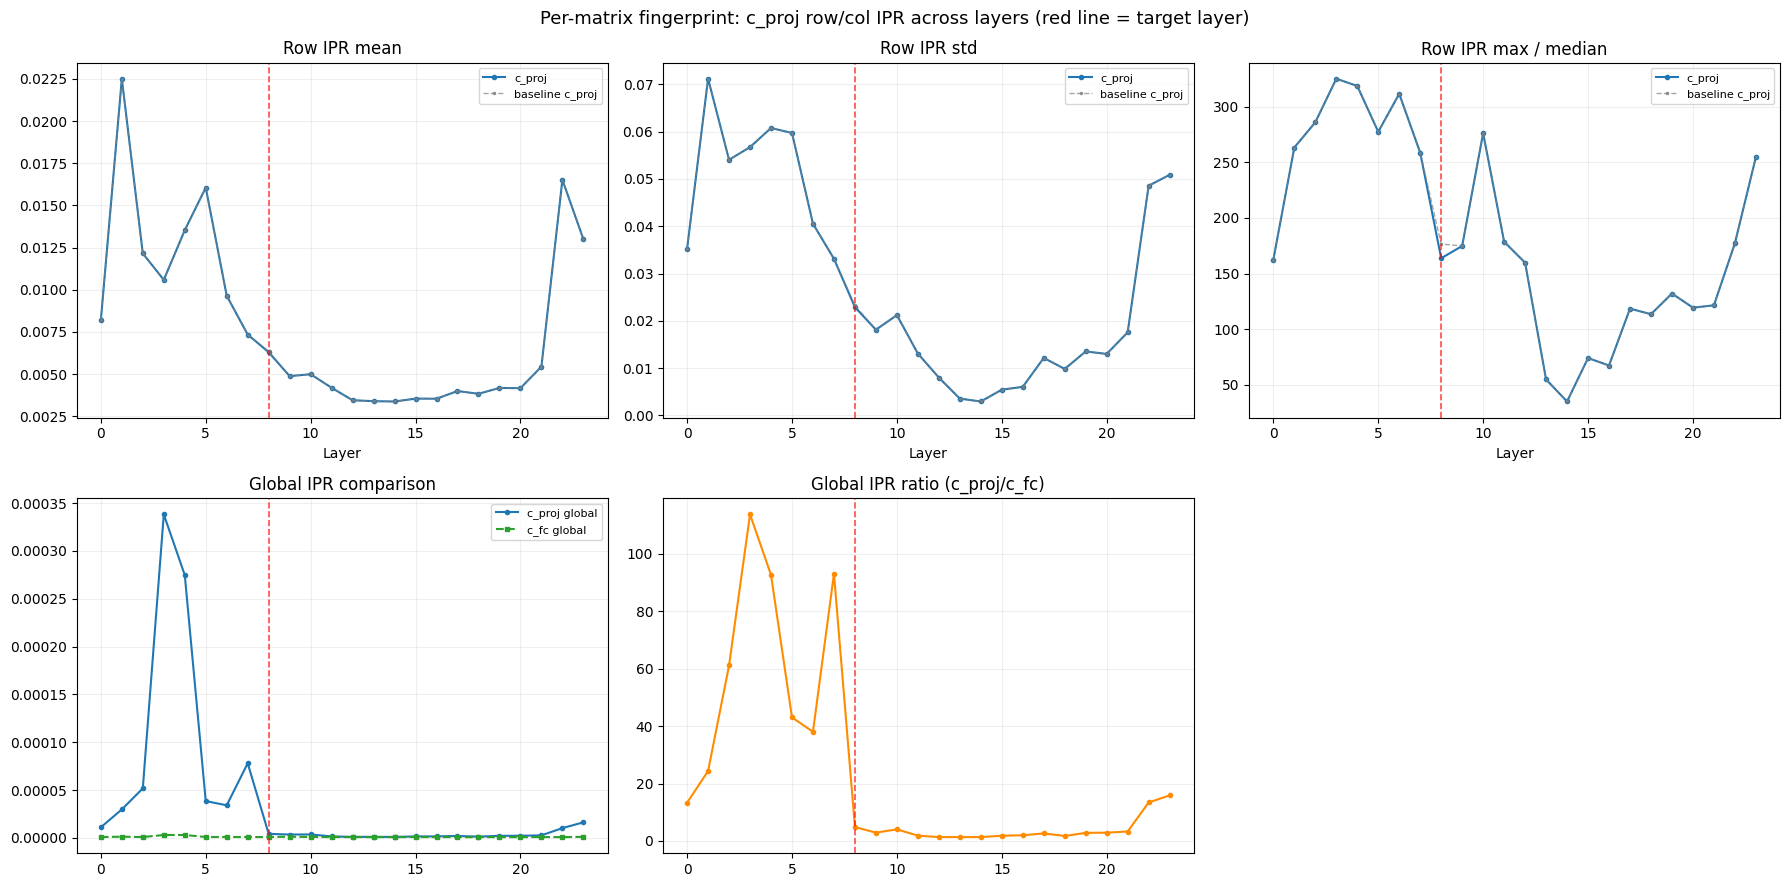

In [13]:
def plot_per_matrix_fingerprint(test_entry, baseline_ipr=None, target_layer=None):
    """Compare c_proj row-IPR distribution across layers, optionally with c_fc."""
    ipr_data = test_entry.get('ipr', {})
    c_proj = ipr_data.get('c_proj', {})
    fvp = ipr_data.get('fc_vs_proj', {})

    if not c_proj:
        print('No c_proj IPR data available.')
        return

    layers = sorted(int(k) for k in c_proj.keys())

    # c_proj stats
    proj_mean = np.array([c_proj[str(l)]['row_ipr_mean'] for l in layers])
    proj_std = np.array([c_proj[str(l)]['row_ipr_std'] for l in layers])
    proj_max = np.array([c_proj[str(l)]['row_ipr_max'] for l in layers])
    proj_median = np.array([c_proj[str(l)]['row_ipr_median'] for l in layers])
    proj_max_over_med = proj_max / (proj_median + 1e-12)

    # Also try extended c_proj data if available
    ext_c_proj = ipr_data.get('extended_c_proj', {})
    has_extended = bool(ext_c_proj)

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    # 1. Row IPR mean
    axes[0, 0].plot(layers, proj_mean, 'o-', markersize=3, linewidth=1.5, color='tab:blue', label='c_proj')
    axes[0, 0].set_title('Row IPR mean')
    axes[0, 0].set_xlabel('Layer')

    # 2. Row IPR std
    axes[0, 1].plot(layers, proj_std, 'o-', markersize=3, linewidth=1.5, color='tab:blue', label='c_proj')
    axes[0, 1].set_title('Row IPR std')
    axes[0, 1].set_xlabel('Layer')

    # 3. Row max / median ratio
    axes[0, 2].plot(layers, proj_max_over_med, 'o-', markersize=3, linewidth=1.5, color='tab:blue', label='c_proj')
    axes[0, 2].set_title('Row IPR max / median')
    axes[0, 2].set_xlabel('Layer')

    # Try to overlay baseline c_proj (if available) to see the edit effect
    if baseline_ipr and 'c_proj' in baseline_ipr:
        bl = baseline_ipr['c_proj']
        bl_mean = np.array([bl[str(l)]['row_ipr_mean'] for l in layers])
        bl_std = np.array([bl[str(l)]['row_ipr_std'] for l in layers])
        bl_max = np.array([bl[str(l)]['row_ipr_max'] for l in layers])
        bl_median = np.array([bl[str(l)]['row_ipr_median'] for l in layers])
        bl_max_over_med = bl_max / (bl_median + 1e-12)

        axes[0, 0].plot(layers, bl_mean, 's--', markersize=2, linewidth=1, color='gray', alpha=0.7, label='baseline c_proj')
        axes[0, 1].plot(layers, bl_std, 's--', markersize=2, linewidth=1, color='gray', alpha=0.7, label='baseline c_proj')
        axes[0, 2].plot(layers, bl_max_over_med, 's--', markersize=2, linewidth=1, color='gray', alpha=0.7, label='baseline c_proj')

    # 4–6: Extended features (skewness, kurtosis, col IPR mean) — if available
    if has_extended:
        for panel_idx, (group, key, title) in enumerate([
            ('row', 'skewness', 'Row IPR skewness'),
            ('row', 'kurtosis', 'Row IPR kurtosis (excess)'),
            ('col', 'max_over_median', 'Col IPR max/median'),
        ]):
            vals = np.array([ext_c_proj[str(l)][group][key] for l in layers])
            ax = axes[1, panel_idx]
            ax.plot(layers, vals, 'o-', markersize=3, linewidth=1.5, color='tab:purple')
            ax.set_title(f'{title} (c_proj only)')
            ax.set_xlabel('Layer')
            ax.grid(True, alpha=0.2)
            if target_layer is not None:
                ax.axvline(int(target_layer), color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    else:
        # Without extended, show c_fc comparison
        if fvp:
            fc_global = np.array([fvp[str(l)]['fc_global_ipr'] for l in layers])
            proj_global = np.array([fvp[str(l)]['proj_global_ipr'] for l in layers])
            ratio = proj_global / (fc_global + 1e-12)

            axes[1, 0].plot(layers, proj_global, 'o-', markersize=3, linewidth=1.5, color='tab:blue', label='c_proj global')
            axes[1, 0].plot(layers, fc_global, 's--', markersize=3, linewidth=1.5, color='tab:green', label='c_fc global')
            axes[1, 0].set_title('Global IPR comparison')
            axes[1, 0].legend(fontsize=8)

            axes[1, 1].plot(layers, ratio, 'o-', markersize=3, linewidth=1.5, color='darkorange')
            axes[1, 1].set_title('Global IPR ratio (c_proj/c_fc)')

            axes[1, 2].set_visible(False)
        else:
            for i in range(3):
                axes[1, i].set_visible(False)

    for ax_row in axes:
        for ax in ax_row:
            if not ax.get_visible():
                continue
            if target_layer is not None:
                ax.axvline(int(target_layer), color='red', linestyle='--', linewidth=1.2, alpha=0.7)
            ax.grid(True, alpha=0.2)
            if ax.get_legend_handles_labels()[1]:
                ax.legend(fontsize=8)

    fig.suptitle('Per-matrix fingerprint: c_proj row/col IPR across layers (red line = target layer)', fontsize=13)
    fig.tight_layout()
    plt.show()

if good_tests:
    baseline_ipr = run_data.get('baseline_ipr')
    plot_per_matrix_fingerprint(good_tests[TEST_INDEX], baseline_ipr=baseline_ipr, target_layer=target_layer)


## Summary: Can blind IPR detect the edited layer?

This cell aggregates evidence from the different blind approaches across **all available test entries** in the current run. For each test we check:

1. **Z-score blind** (gap + ratio + smoothness): does the combined score peak at the target?
2. **IPRDetector** (from benchmark): if available, what layer did it pick?
3. **Top-3 rank**: is the target layer within the top-3 scored layers?

We also report any systematic patterns (e.g., do boundary layers consistently get high scores, masking the target?).


=== BLIND IPR DETECTION SUMMARY (1 tests, target layer 8) ===

Z-score blind (gap + ratio + smoothness):
  Top-1 accuracy:   0/1 (0.0%)
  Top-3 accuracy:   0/1 (0.0%)
  Target rank:      mean=6.0, median=6, min=6, max=6
  Target score:     mean=3.704, std=0.000

IPR Detector (from benchmark):
  Top-1 accuracy:   0/1 (0.0%)
  Top-3 accuracy:   0/1 (0.0%)


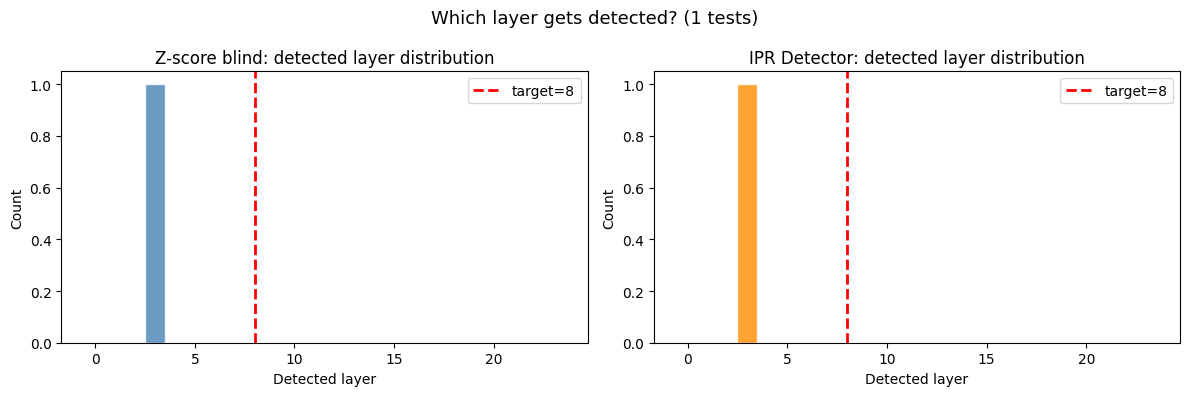


--- Conclusion ---
✗ Blind IPR z-score struggles (0/1). The ROME edit produces a very small IPR footprint in the weight space.


In [14]:
def final_summary(tests, target_layer, trim_first=2, trim_last=2):
    """Comprehensive summary of blind IPR detection across all tests."""
    n = len(tests)
    if n == 0:
        print('No tests to analyse.')
        return

    zscore_correct = 0
    zscore_top3 = 0
    ipr_det_correct = 0
    ipr_det_top3 = 0
    detected_layers_zscore = []
    detected_layers_det = []
    target_ranks_zscore = []
    target_scores = []

    for t in tests:
        fvp = t.get('ipr', {}).get('fc_vs_proj', {})
        if not fvp:
            continue
        layers = sorted(int(k) for k in fvp.keys())
        gap = np.array([fvp[str(l)]['global_ipr_gap'] for l in layers])
        ratio = np.array([fvp[str(l)]['global_ipr_ratio_proj_over_fc'] for l in layers])

        def z(arr):
            m, s = arr.mean(), arr.std()
            return (arr - m) / (s if s > 0 else 1.0)

        def smooth_z(arr):
            d2 = np.zeros_like(arr)
            d2[1:-1] = arr[2:] - 2*arr[1:-1] + arr[:-2]
            return z(d2)

        combined = np.abs(z(gap)) + np.abs(smooth_z(gap)) + np.abs(z(ratio)) + np.abs(smooth_z(ratio))
        nl = len(layers)
        combined[:trim_first] = 0
        combined[-trim_last:] = 0

        detected = layers[np.argmax(combined)]
        detected_layers_zscore.append(detected)
        if detected == target_layer:
            zscore_correct += 1

        ranking = sorted(enumerate(combined.tolist()), key=lambda x: x[1], reverse=True)
        ranked_layers = [layers[i] for i, _ in ranking]
        if target_layer in ranked_layers[:3]:
            zscore_top3 += 1

        # Target rank (1-indexed)
        if target_layer in ranked_layers:
            target_ranks_zscore.append(ranked_layers.index(target_layer) + 1)
            target_idx = layers.index(target_layer)
            target_scores.append(combined[target_idx])

        # IPR detector results
        det = t.get('ipr', {}).get('ipr_detection', {})
        if det:
            dl = det.get('anomalous_layer')
            detected_layers_det.append(dl)
            if dl == target_layer:
                ipr_det_correct += 1
            det_ranking = det.get('ranking', [])
            if target_layer in [r[0] for r in det_ranking[:3]]:
                ipr_det_top3 += 1

    print(f'=== BLIND IPR DETECTION SUMMARY ({n} tests, target layer {target_layer}) ===\n')

    print('Z-score blind (gap + ratio + smoothness):')
    print(f'  Top-1 accuracy:   {zscore_correct}/{n} ({zscore_correct/n*100:.1f}%)')
    print(f'  Top-3 accuracy:   {zscore_top3}/{n} ({zscore_top3/n*100:.1f}%)')
    if target_ranks_zscore:
        print(f'  Target rank:      mean={np.mean(target_ranks_zscore):.1f}, median={np.median(target_ranks_zscore):.0f}, '
              f'min={min(target_ranks_zscore)}, max={max(target_ranks_zscore)}')
        print(f'  Target score:     mean={np.mean(target_scores):.3f}, std={np.std(target_scores):.3f}')

    if detected_layers_det:
        print(f'\nIPR Detector (from benchmark):')
        print(f'  Top-1 accuracy:   {ipr_det_correct}/{n} ({ipr_det_correct/n*100:.1f}%)')
        print(f'  Top-3 accuracy:   {ipr_det_top3}/{n} ({ipr_det_top3/n*100:.1f}%)')

    # Histogram of detected layers
    if detected_layers_zscore:
        fig, axes = plt.subplots(1, 2 if detected_layers_det else 1, figsize=(12 if detected_layers_det else 7, 4))
        if not isinstance(axes, np.ndarray):
            axes = [axes]

        all_layers = sorted(set(int(k) for k in fvp.keys()))
        bins = np.arange(min(all_layers) - 0.5, max(all_layers) + 1.5, 1)

        axes[0].hist(detected_layers_zscore, bins=bins, color='steelblue', alpha=0.8, edgecolor='white')
        axes[0].axvline(target_layer, color='red', linestyle='--', linewidth=2, label=f'target={target_layer}')
        axes[0].set_title('Z-score blind: detected layer distribution')
        axes[0].set_xlabel('Detected layer')
        axes[0].set_ylabel('Count')
        axes[0].legend()

        if detected_layers_det:
            axes[1].hist(detected_layers_det, bins=bins, color='darkorange', alpha=0.8, edgecolor='white')
            axes[1].axvline(target_layer, color='red', linestyle='--', linewidth=2, label=f'target={target_layer}')
            axes[1].set_title('IPR Detector: detected layer distribution')
            axes[1].set_xlabel('Detected layer')
            axes[1].set_ylabel('Count')
            axes[1].legend()

        fig.suptitle(f'Which layer gets detected? ({n} tests)', fontsize=13)
        fig.tight_layout()
        plt.show()

    # Conclusion
    print('\n--- Conclusion ---')
    if zscore_correct == n:
        print('✓ Blind IPR z-score correctly identifies the edited layer in ALL tests!')
    elif zscore_correct / n >= 0.5:
        print(f'~ Blind IPR z-score works in {zscore_correct}/{n} tests — moderate signal.')
    else:
        print(f'✗ Blind IPR z-score struggles ({zscore_correct}/{n}). '
              'The ROME edit produces a very small IPR footprint in the weight space.')
        if target_ranks_zscore and np.mean(target_ranks_zscore) <= 5:
            print(f'  However, the target is usually near the top (mean rank {np.mean(target_ranks_zscore):.1f}). '
                  'Boundary noise may be the main interference.')

final_summary(good_tests, target_layer)
